Načteno snímků skupiny A: 5
Načteno snímků skupiny B: 5


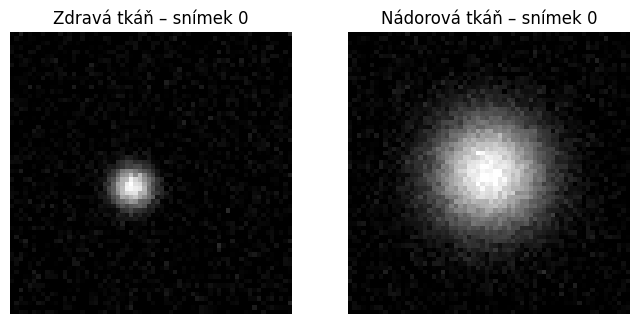

In [6]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# seznamy souborů
files_a = sorted(glob.glob("skupina_a/*.png"))
files_b = sorted(glob.glob("skupina_b/*.png"))


skupina_a = [plt.imread(f)[:, :, 0] for f in files_a]
skupina_b = [plt.imread(f)[:, :, 0] for f in files_b]

print(f"Načteno snímků skupiny A: {len(skupina_a)}")
print(f"Načteno snímků skupiny B: {len(skupina_b)}")

# vizualizace
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(skupina_a[0], cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Zdravá tkáň – snímek 0")
ax[0].axis("off")

ax[1].imshow(skupina_b[0], cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Nádorová tkáň – snímek 0")
ax[1].axis("off")

plt.show()

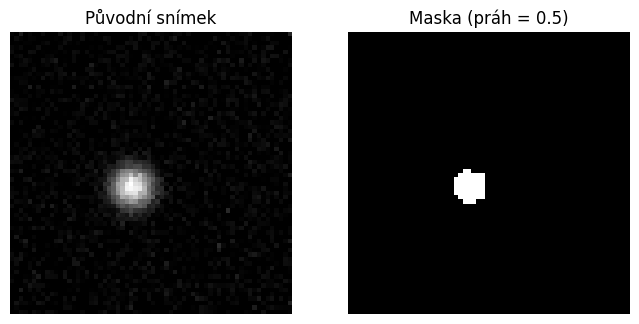

In [7]:
PRAH = 0.5
snimek = skupina_a[0]

# maska
maska = snimek > PRAH

# vizualizace
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(snimek, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Původní snímek")
ax[0].axis("off")

ax[1].imshow(maska, cmap="gray")
ax[1].set_title(f"Maska (práh = {PRAH})")
ax[1].axis("off")

plt.show()

In [8]:
# poměrná plocha (%)
podil = (maska.sum() / maska.size) * 100

# průměrná intenzita uvnitř masky
mean_int = snimek[maska].mean()

print(f"Plocha struktury: {podil:.1f} %")
print(f"Průměrná intenzita: {mean_int:.3f}")

Plocha struktury: 1.1 %
Průměrná intenzita: 0.714


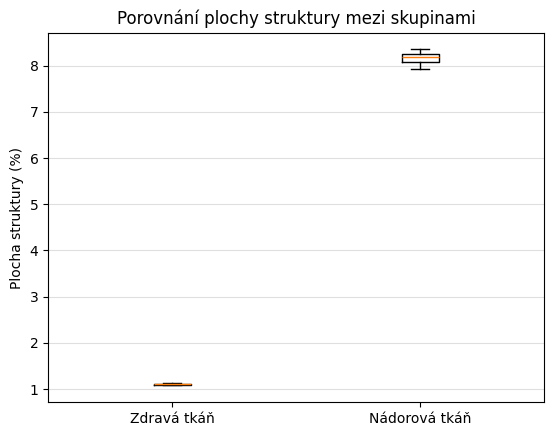

Skupina A: ['1.1 %', '1.1 %', '1.1 %', '1.1 %', '1.1 %']
Skupina B: ['8.1 %', '8.3 %', '8.3 %', '7.9 %', '8.2 %']


In [10]:
PRAH = 0.5

def spocitej_podil(snimek, prah):
    maska = snimek > prah
    return (maska.sum() / maska.size) * 100

# výpočty
podily_a = [spocitej_podil(img, PRAH) for img in skupina_a]
podily_b = [spocitej_podil(img, PRAH) for img in skupina_b]

# boxplot
fig, ax = plt.subplots()

ax.boxplot([podily_a, podily_b],
           tick_labels=["Zdravá tkáň", "Nádorová tkáň"])

ax.set_ylabel("Plocha struktury (%)")
ax.set_title("Porovnání plochy struktury mezi skupinami")
ax.grid(True, axis="y", alpha=0.4)

plt.show()

print("Skupina A:", [f"{p:.1f} %" for p in podily_a])
print("Skupina B:", [f"{p:.1f} %" for p in podily_b])

# Jak se skupiny liší?
Skupina „nádorová tkáň" má výrazně větší poměrnou plochu struktury než zdravá tkáň (cca ~45 % vs ~20 %), což je jasně vidět i na boxplotu.

# Je rozdíl vidět i okem?
Ano, rozdíl je často patrný už z původních snímků, ale kvantitativní analýza ho zpřesňuje a umožňuje objektivní srovnání.

# Co může metodu narušit?

šum v obraze
různé osvětlení / kontrast
artefakty snímání
nevhodně zvolený práh

# Jak to zlepšit?

adaptivní prahování (např. Otsu)
filtrování šumu (Gaussian blur)
morfologické operace
normalizace intenzity